# Nghiên Cứu Ablation Study: Đánh Giá 5 Biến Thể Mamba-Hybrid

Notebook này thực hiện so sánh hiệu năng của 5 biến thể trong nghiên cứu **Ablation Study** của mô hình `Mamba-Hybrid` nhằm đánh giá vai trò của từng thành phần cốt lõi under a fixed parameter budget (~330k - 345k):
1. **Variant 1 (SimpleMamba)**: Mô hình Mamba cơ bản (point-wise, không patching, không decomposition, không stats).
2. **Variant 2 (PatchedMamba)**: Mô hình Mamba với Linear Patching.
3. **Variant 3 (Mamba + CNN)**: Thêm Multiscale CNN Patching.
4. **Variant 4 (Mamba + Series Decomposition)**: Thêm Series Decomposition tách xu hướng/chu kỳ.
5. **Variant 5 (Complete Hybrid)**: Thêm Stats Head (kết hợp đặc trưng thống kê vật lý, mô hình hoàn chỉnh đề xuất).

Tất cả các biến thể được tự động điều chỉnh `d_model` (auto-scaling) để đảm bảo công bằng về mặt tham số (cố định ngân sách tham số ~337k).

In [1]:
# !pip install mamba-ssm --no-build-isolation

In [2]:
import os
import sys
import time
import gc
import yaml
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import precision_recall_curve, auc as auc_score_func

# Phát hiện môi trường Kaggle và cấu hình đường dẫn dữ liệu
is_kaggle = os.path.exists('/kaggle')
print(f'Is running on Kaggle: {is_kaggle}')

if is_kaggle:
    kaggle_source_root = '/kaggle/input/datasets/sunbv21/mamba-sft-source'
    if kaggle_source_root not in sys.path:
        sys.path.append(kaggle_source_root)
    project_root = kaggle_source_root
    
    train_dirs = ["/kaggle/input/datasets/sunbv21/dataset-bearings/B02", 
                  "/kaggle/input/datasets/sunbv21/dataset-bearings/B05"]
    test_dirs = ["/kaggle/input/datasets/sunbv21/dataset-bearings/B01",
                 "/kaggle/input/datasets/sunbv21/dataset-bearings/B03",
                 "/kaggle/input/datasets/sunbv21/dataset-bearings/B04",
                 "/kaggle/input/datasets/sunbv21/dataset-bearings/B05"]
    models_dir = "/kaggle/working/results/models"
    print(f'-> [Kaggle] project_root: {project_root}')
    print(f'-> [Kaggle] models_dir: {models_dir}')
else:
    project_root = os.path.abspath("../")
    if project_root not in sys.path:
        sys.path.append(project_root)
        
    # train_dirs = ["data/processed/B02", "data/processed/B05"]
    # test_dirs = ["data/processed/B01", "data/processed/B03", "data/processed/B04", "data/processed/B05"]
    train_dirs = ["data/processed/B02"]
    test_dirs = ["data/processed/B01", "data/processed/B03"]
    train_dirs = [os.path.join(project_root, d) for d in train_dirs]
    test_dirs = [os.path.join(project_root, d) for d in test_dirs]
    models_dir = os.path.join(project_root, "results/models")
    print(f'-> [Local] project_root: {project_root}')
    print(f'-> [Local] models_dir: {models_dir}')

from src.data import MultiBearingDataset
from src.models.mamba import HybridMambaCNN, SimpleMamba
from src.evaluation.anomaly_scorer import calculate_anomaly_score
from src.evaluation.metrics import (
    calculate_threshold_3sigma, calculate_threshold_robust, 
    calculate_threshold_percentile, calculate_threshold_pot,
    calculate_threshold_gmm, find_best_threshold, calculate_metrics
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Is running on Kaggle: False
-> [Local] project_root: /mnt/f/APPS_PJ/mamba-forecast-ad
-> [Local] models_dir: /mnt/f/APPS_PJ/mamba-forecast-ad/results/models
Using device: cuda


In [3]:
# Tải cấu hình nền (Full) để thiết lập dataset và các tham số khác
configs_dir = os.path.join(project_root, "configs")
base_config_path = os.path.join(configs_dir, "snano_full.yaml")

if os.path.exists(base_config_path):
    with open(base_config_path, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)
else:
    config = {'data': {}, 'model': {}, 'training': {}}

# Áp dụng cấu hình yêu cầu
lookback = 512
horizon = 128
patch_size = 16
window_stride = 1024
stride = 8
trend_downsample = 64
cnn_out_channels = 64
mamba_n_layer = 4
mamba_d_state = 16
mamba_d_conv = 3
mamba_expand = 3
bidirectional = False
decomp_kernel = 25

sampling_rate = config['data'].get('sampling_rate', 128000)
highpass_freq = config['data'].get('highpass_freq', 2000)
train_ratio = config['data'].get('train_ratio', 0.4)
skip_ratio = config['data'].get('skip_ratio', 0.05)
label_strategy = 'manual'
manual_fault_start = {
    "B01": "data_B01_M0208.pt",
    "B03": "data_B03_M0547.pt"
}
batch_size = 128

print("Đang tải dữ liệu huấn luyện để trích xuất thống kê Operating Conditions (oc_stats)...")
train_dataset = MultiBearingDataset(
    train_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='train',
    file_sample_ratio=1, train_ratio=train_ratio, skip_ratio=skip_ratio,
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate, label_strategy=label_strategy, manual_fault_start=manual_fault_start
)
oc_stats = train_dataset.oc_stats

print("Đang tải dữ liệu validation...")
val_dataset = MultiBearingDataset(
    train_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='val',
    file_sample_ratio=1, oc_stats=oc_stats, train_ratio=train_ratio, skip_ratio=skip_ratio,
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate, label_strategy=label_strategy, manual_fault_start=manual_fault_start
)

print("Đang tải tập dữ liệu kiểm thử (4 Vòng Bi)...")
test_dataset = MultiBearingDataset(
    test_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='test',
    file_sample_ratio=1, oc_stats=oc_stats, train_ratio=train_ratio, skip_ratio=skip_ratio,
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate, label_strategy=label_strategy, manual_fault_start=manual_fault_start
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n--- Tải dữ liệu thành công ---")
print(f"Số lượng mẫu test: {len(test_dataset):,}")

Đang tải dữ liệu huấn luyện để trích xuất thống kê Operating Conditions (oc_stats)...
Đang tải dữ liệu validation...
Đang tải tập dữ liệu kiểm thử (4 Vòng Bi)...

--- Tải dữ liệu thành công ---
Số lượng mẫu test: 198,200


In [4]:
from src.training.train import count_parameters, find_closest_simple_mamba

# Định nghĩa các variant configs và auto-scaling
# Chúng ta sẽ tính số lượng tham số mục tiêu từ Variant 5
target_model_cfg = {
    'mamba_version': 1,
    'mamba_d_model': 64,
    'mamba_n_layer': mamba_n_layer,
    'mamba_d_state': mamba_d_state,
    'mamba_d_conv': mamba_d_conv,
    'mamba_expand': mamba_expand,
    'forecast_len': horizon,
    'patch_size': patch_size,
    'stride': stride,
    'trend_downsample': trend_downsample,
    'in_channels': 2,
    'lookback': lookback,
    'decomp_kernel': decomp_kernel,
    'use_multiscale': True,
    'use_revin': False,
    'use_decomposition': True,
    'use_stats': True
}

# Khởi tạo mô hình Variant 5 làm mốc tham chiếu
v6_dummy = HybridMambaCNN({'model': target_model_cfg})
v6_params = count_parameters(v6_dummy)
print(f"Target Parameter Budget (Variant 5): {v6_params:,}")

# Tìm d_model tối ưu cho các HybridMambaCNN variants (Variant 2, 3, 4)
def find_closest_hybrid_d_model(target, use_decomp, use_multiscale, use_stats):
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for d in range(8, 256, 2):
        model = HybridMambaCNN({
            'model': {
                'mamba_version': 1, 'mamba_d_model': d, 'mamba_n_layer': mamba_n_layer,
                'mamba_d_state': mamba_d_state, 'mamba_d_conv': mamba_d_conv, 'mamba_expand': mamba_expand,
                'forecast_len': horizon, 'patch_size': patch_size, 'stride': stride,
                'trend_downsample': trend_downsample, 'in_channels': 2, 'lookback': lookback,
                'decomp_kernel': decomp_kernel, 'use_multiscale': use_multiscale, 'use_revin': False,
                'use_decomposition': use_decomp, 'use_stats': use_stats
            }
        })
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = d
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params

v4_d_model, v4_params = find_closest_hybrid_d_model(v6_params, use_decomp=True, use_multiscale=False, use_stats=False)
v3_d_model, v3_params = find_closest_hybrid_d_model(v6_params, use_decomp=False, use_multiscale=True, use_stats=False)
v2_d_model, v2_params = find_closest_hybrid_d_model(v6_params, use_decomp=False, use_multiscale=False, use_stats=False)

# Tìm d_model tối ưu cho SimpleMamba (Variant 1)
v1_d_model, v1_params = find_closest_simple_mamba(
    v6_params, lookback, horizon,
    mamba_n_layer=mamba_n_layer, mamba_d_state=mamba_d_state,
    mamba_d_conv=mamba_d_conv, mamba_expand=mamba_expand, mamba_version=1
)

ablation_variants = {
    "Variant_1_SimpleMamba": {
        "class": "SimpleMamba",
        "d_model": v1_d_model,
        "params": v1_params,
        "cfg": {
            'mamba_version': 1, 'mamba_d_model': v1_d_model, 'mamba_n_layer': mamba_n_layer,
            'mamba_d_state': mamba_d_state, 'mamba_d_conv': mamba_d_conv, 'mamba_expand': mamba_expand,
            'forecast_len': horizon, 'in_channels': 2, 'lookback': lookback
        }
    },
    "Variant_2_PatchedMamba": {
        "class": "HybridMambaCNN",
        "d_model": v2_d_model,
        "params": v2_params,
        "cfg": {
            'mamba_version': 1, 'mamba_d_model': v2_d_model, 'mamba_n_layer': mamba_n_layer,
            'mamba_d_state': mamba_d_state, 'mamba_d_conv': mamba_d_conv, 'mamba_expand': mamba_expand,
            'forecast_len': horizon, 'patch_size': patch_size, 'stride': stride,
            'trend_downsample': trend_downsample, 'in_channels': 2, 'lookback': lookback,
            'decomp_kernel': decomp_kernel, 'use_multiscale': False, 'use_revin': False,
            'use_decomposition': False, 'use_stats': False
        }
    },
    "Variant_3_Mamba_CNN": {
        "class": "HybridMambaCNN",
        "d_model": v3_d_model,
        "params": v3_params,
        "cfg": {
            'mamba_version': 1, 'mamba_d_model': v3_d_model, 'mamba_n_layer': mamba_n_layer,
            'mamba_d_state': mamba_d_state, 'mamba_d_conv': mamba_d_conv, 'mamba_expand': mamba_expand,
            'forecast_len': horizon, 'patch_size': patch_size, 'stride': stride,
            'trend_downsample': trend_downsample, 'in_channels': 2, 'lookback': lookback,
            'decomp_kernel': decomp_kernel, 'use_multiscale': True, 'use_revin': False,
            'use_decomposition': False, 'use_stats': False
        }
    },
    "Variant_4_Mamba_Decomp": {
        "class": "HybridMambaCNN",
        "d_model": v4_d_model,
        "params": v4_params,
        "cfg": {
            'mamba_version': 1, 'mamba_d_model': v4_d_model, 'mamba_n_layer': mamba_n_layer,
            'mamba_d_state': mamba_d_state, 'mamba_d_conv': mamba_d_conv, 'mamba_expand': mamba_expand,
            'forecast_len': horizon, 'patch_size': patch_size, 'stride': stride,
            'trend_downsample': trend_downsample, 'in_channels': 2, 'lookback': lookback,
            'decomp_kernel': decomp_kernel, 'use_multiscale': False, 'use_revin': False,
            'use_decomposition': True, 'use_stats': False
        }
    },
    "Variant_5_NoStats": {
        "class": "HybridMambaCNN",
        "d_model": 64,
        "params": v6_params,
        "cfg": {
            'mamba_version': 1, 'mamba_d_model': 64, 'mamba_n_layer': mamba_n_layer,
            'mamba_d_state': mamba_d_state, 'mamba_d_conv': mamba_d_conv, 'mamba_expand': mamba_expand,
            'forecast_len': horizon, 'patch_size': patch_size, 'stride': stride,
            'trend_downsample': trend_downsample, 'in_channels': 2, 'lookback': lookback,
            'decomp_kernel': decomp_kernel, 'use_multiscale': True, 'use_revin': False,
            'use_decomposition': True, 'use_stats': False
        }
    },
    "Variant_6_Complete": {
        "class": "HybridMambaCNN",
        "d_model": 64,
        "params": v6_params,
        "cfg": target_model_cfg
    }
}

print("\n--- Báo cáo Cấu hình Tự động Điều chỉnh tham số (Auto-scaling Baseline) ---")
for name, info in ablation_variants.items():
    print(f"* {name:<22}: d_model={info['d_model']:<3} | Params={info['params']:,} | Diff to Target={abs(info['params'] - v6_params):,}")

Target Parameter Budget (Variant 5): 206,994

--- Báo cáo Cấu hình Tự động Điều chỉnh tham số (Auto-scaling Baseline) ---
* Variant_1_SimpleMamba : d_model=64  | Params=204,032 | Diff to Target=2,962
* Variant_2_PatchedMamba: d_model=64  | Params=206,146 | Diff to Target=848
* Variant_3_Mamba_CNN   : d_model=64  | Params=205,954 | Diff to Target=1,040
* Variant_4_Mamba_Decomp: d_model=64  | Params=206,146 | Diff to Target=848
* Variant_5_NoStats     : d_model=64  | Params=206,994 | Diff to Target=0
* Variant_6_Complete    : d_model=64  | Params=206,994 | Diff to Target=0


In [5]:
def instantiate_variant(variant_name):
    info = ablation_variants[variant_name]
    m_class = info["class"]
    m_cfg = info["cfg"]
    
    if m_class == "SimpleMamba":
        model = SimpleMamba({'model': m_cfg})
    else:
        model = HybridMambaCNN({
            'model': m_cfg,
            'data': {
                'patch_size': m_cfg.get('patch_size', patch_size),
                'stride': m_cfg.get('stride', stride),
                'lookback': lookback
            }
        })
    return model

def load_variant_checkpoint(variant_name, model, device):
    checkpoint_name = f"mamba1_hybrid_snano_{variant_name.lower()}_best.pth"
    checkpoint_path = os.path.join(models_dir, checkpoint_name)
    
    if os.path.exists(checkpoint_path):
        print(f"Đang tải checkpoint: {checkpoint_name}...")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    else:
        print(f"⚠️ CẢNH BÁO: Không tìm thấy checkpoint cho {variant_name} tại {checkpoint_path}. Mô hình sẽ khởi chạy ngẫu nhiên!")
        
    model.to(device)
    model.eval()
    return model

In [6]:
def evaluate_variant(variant_name, model, test_loader, device):
    model.eval()
    
    macro_metrics = {
        t_name: {"F1": [], "FAR": [], "AUC": [], "AUPRC": []}
        for t_name in ["3-Sigma", "Robust", "Percentile", "POT", "Self-Learn", "Optimal"]
    }
    
    macro_forecasting = {
        "MAE": [], "MSE": [], "RMSE": [], "MAPE": []
    }
    
    # Khởi tạo các danh sách đo độ trễ chi tiết
    transfer_latencies = []
    inf_latencies = []
    scoring_latencies = []
    decision_latencies = []
    total_eval_latencies = []
    
    calib_times = {
        "3-Sigma": [],
        "Robust": [],
        "Percentile": [],
        "POT": [],
        "Self-Learn": [],
        "Optimal": []
    }
    
    test_datasets = test_loader.dataset.datasets if hasattr(test_loader.dataset, 'datasets') else [test_loader.dataset]

    # Khởi động lại theo dõi peak VRAM cho phase evaluate
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        
    for test_idx, ds in enumerate(test_datasets):
        bearing_name = os.path.basename(ds.data_dir) if hasattr(ds, 'data_dir') else f"Bearing_{test_idx}"
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
        
        bearing_scores = []
        bearing_rms = []
        bearing_kurt = []
        bearing_labels = []
        bearing_mae_list = []
        bearing_mse_list = []
        bearing_mape_list = []
        
        with torch.no_grad():
            for batch in loader:
                # 1. Đo lường thời gian truyền dữ liệu (CPU -> GPU)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t0 = time.time()
                
                x = batch[0].to(device)
                y = batch[1].to(device)
                stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t1 = time.time()
                
                # 2. Đo lường thời gian Model Inference (Forward Pass) với Autocast
                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    if stats is not None and isinstance(model, HybridMambaCNN) and model.use_stats:
                        y_pred = model(x, stats)
                    else:
                        y_pred = model(x)
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t2 = time.time()
                
                # 3. Đo lường thời gian Tính điểm bất thường (Anomaly Scoring)
                scores = calculate_anomaly_score(y, y_pred, metric='mse', normalized=False)
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t3 = time.time()
                
                # 4. Đo lường thời gian Ra quyết định (Threshold Decision)
                dummy_threshold = 0.5
                is_anomaly = scores > dummy_threshold
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t4 = time.time()
                
                # Lưu trữ kết quả đo lường độ trễ trên mỗi sample (ms/sample)
                n_samples = x.size(0)
                transfer_ms = (t1 - t0) * 1000 / n_samples
                inf_ms = (t2 - t1) * 1000 / n_samples
                score_ms = (t3 - t2) * 1000 / n_samples
                decision_ms = (t4 - t3) * 1000 / n_samples
                total_ms = (t4 - t0) * 1000 / n_samples
                
                transfer_latencies.append(transfer_ms)
                inf_latencies.append(inf_ms)
                scoring_latencies.append(score_ms)
                decision_latencies.append(decision_ms)
                total_eval_latencies.append(total_ms)
                
                bearing_scores.extend(scores.tolist())

                if stats is not None:
                    # stats has shape [batch_size, channels, 8]
                    # rms is index 2, kurtosis is index 5
                    rms_sample = stats[:, :, 2].mean(dim=-1).cpu().numpy().tolist()
                    kurt_sample = stats[:, :, 5].mean(dim=-1).cpu().numpy().tolist()
                    bearing_rms.extend(rms_sample)
                    bearing_kurt.extend(kurt_sample)
                else:
                    bearing_rms.extend([0.0] * x.size(0))
                    bearing_kurt.extend([3.0] * x.size(0))

                if len(batch) > 3:
                    bearing_labels.extend(batch[3].cpu().numpy().tolist())
                else:
                    bearing_labels.extend([0] * x.size(0))

                y_cpu = y.detach().cpu().numpy()
                y_pred_cpu = y_pred.detach().cpu().numpy()
                
                batch_mae = np.mean(np.abs(y_cpu - y_pred_cpu))
                batch_mse = np.mean((y_cpu - y_pred_cpu) ** 2)
                epsilon = 1e-5
                batch_mape = np.mean(np.abs(y_cpu - y_pred_cpu) / (np.abs(y_cpu) + epsilon)) * 100
                
                bearing_mae_list.append(batch_mae)
                bearing_mse_list.append(batch_mse)
                bearing_mape_list.append(batch_mape)

        bearing_scores = np.array(bearing_scores)
        bearing_labels = np.array(bearing_labels, dtype=int)
        
        n_total = len(bearing_labels)
        
        bearing_mae = np.mean(bearing_mae_list)
        bearing_mse = np.mean(bearing_mse_list)
        bearing_rmse = np.sqrt(bearing_mse)
        bearing_mape = np.mean(bearing_mape_list)
        
        macro_forecasting["MAE"].append(bearing_mae)
        macro_forecasting["MSE"].append(bearing_mse)
        macro_forecasting["RMSE"].append(bearing_rmse)
        macro_forecasting["MAPE"].append(bearing_mape)
        
        # Thiết lập khoảng dữ liệu healthy tính ngưỡng
        skip_end = int(n_total * skip_ratio)
        train_end = int(n_total * (skip_ratio + train_ratio))
        
        normal_indices = np.where(bearing_labels == 0)[0]
        if len(normal_indices) > 0:
            train_end = min(train_end, normal_indices[-1] + 1)
            
        if train_end > skip_end:
            healthy_subset = bearing_scores[skip_end:train_end]
            healthy_labels = bearing_labels[skip_end:train_end]
            healthy_scores = healthy_subset[healthy_labels == 0]
            if len(healthy_scores) == 0:
                healthy_scores = bearing_scores[:max(1, int(n_total * 0.1))]
        else:
            healthy_scores = bearing_scores[:max(1, int(n_total * 0.1))]
            
        # Đo lường thời gian hiệu chuẩn từng thuật toán ngưỡng
        t_cal = time.time()
        local_th_3s  = calculate_threshold_3sigma(healthy_scores)
        calib_times["3-Sigma"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_rb  = calculate_threshold_robust(healthy_scores)
        calib_times["Robust"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_pc  = calculate_threshold_percentile(healthy_scores, q=99.7)
        calib_times["Percentile"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_pot = calculate_threshold_pot(healthy_scores, q=1e-3)
        calib_times["POT"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_gmm = calculate_threshold_gmm(bearing_scores)
        calib_times["Self-Learn"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_opt, _ = find_best_threshold(bearing_scores, bearing_labels)
        calib_times["Optimal"].append((time.time() - t_cal) * 1000)

        if len(np.unique(bearing_labels)) > 1:
            precision_path, recall_path, _ = precision_recall_curve(bearing_labels, bearing_scores)
            bearing_auprc = auc_score_func(recall_path, precision_path)
        else:
            bearing_auprc = 0.0

        thresholds = [
            ("3-Sigma", local_th_3s), ("Robust", local_th_rb), ("Percentile", local_th_pc),
            ("POT", local_th_pot), ("Self-Learn", local_th_gmm), ("Optimal", local_th_opt)
        ]
        
        for t_name, t_val in thresholds:
            m = calculate_metrics(bearing_scores, bearing_labels, t_val)
            macro_metrics[t_name]["F1"].append(m.get('F1', 0))
            macro_metrics[t_name]["FAR"].append(m.get('FAR', 0))
            macro_metrics[t_name]["AUC"].append(m.get('AUC', 0))
            macro_metrics[t_name]["AUPRC"].append(bearing_auprc)

        # Tích hợp lưu trữ kết quả để so sánh 2x2 ở mức sample (chi tiết hơn)
        if 'comparison_results' not in globals():
            globals()['comparison_results'] = {}
        global_comp = globals()['comparison_results']
        if bearing_name not in global_comp:
            global_comp[bearing_name] = {}
        
        global_comp[bearing_name][variant_name] = {
            'mse': bearing_scores,
            'file_indices': [ds.samples[i][0] for i in range(len(bearing_scores))],
            'files': ds.files,
            'rms': bearing_rms,
            'kurtosis': bearing_kurt
        }


    # Lấy Peak VRAM cho evaluation
    peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0.0

    avg_transfer_lat = float(np.mean(transfer_latencies))
    avg_inf_lat = float(np.mean(inf_latencies))
    avg_scoring_lat = float(np.mean(scoring_latencies))
    avg_decision_lat = float(np.mean(decision_latencies))
    avg_total_eval_lat = float(np.mean(total_eval_latencies))
    avg_calib_times = {k: float(np.mean(v)) for k, v in calib_times.items()}
    
    avg_mae = float(np.mean(macro_forecasting["MAE"]))
    avg_mse = float(np.mean(macro_forecasting["MSE"]))
    avg_rmse = float(np.mean(macro_forecasting["RMSE"]))
    avg_mape = float(np.mean(macro_forecasting["MAPE"]))

    print(f"\n============================================================")
    print(f">>> MACRO-AVERAGE PERFORMANCE - VARIANT: {variant_name}")
    print(f"   [Forecasting] > MAE: {avg_mae:.6f} | MSE: {avg_mse:.6f} | RMSE: {avg_rmse:.6f} | MAPE: {avg_mape:.4f}%")
    print(f"   [Resource]    > Peak VRAM: {peak_vram:.2f} MB")
    print(f"   [Latency Breakdown (per sample)]:")
    print(f"     * Data Transfer:  {avg_transfer_lat:.4f} ms")
    print(f"     * Model Inference: {avg_inf_lat:.4f} ms")
    print(f"     * Anomaly Scoring: {avg_scoring_lat:.4f} ms")
    print(f"     * Decision:        {avg_decision_lat:.4f} ms")
    print(f"     * TOTAL LATENCY:   {avg_total_eval_lat:.4f} ms/sample")
    print(f"============================================================")
    
    res_dict = {
        "MAE": avg_mae,
        "MSE": avg_mse,
        "RMSE": avg_rmse,
        "MAPE": avg_mape,
        "VRAM Inference (MB)": peak_vram,
        "Latency (ms)": avg_total_eval_lat,
        "Lat Transfer (ms)": avg_transfer_lat,
        "Lat Inference (ms)": avg_inf_lat,
        "Lat Scoring (ms)": avg_scoring_lat,
        "Lat Decision (ms)": avg_decision_lat,
    }
    
    for t_name in ["3-Sigma", "Robust", "Percentile", "POT", "Self-Learn", "Optimal"]:
        res_dict[f"F1 ({t_name})"] = np.mean(macro_metrics[t_name]["F1"])
        res_dict[f"FAR ({t_name})"] = np.mean(macro_metrics[t_name]["FAR"])
        res_dict[f"AUC ({t_name})"] = np.mean(macro_metrics[t_name]["AUC"])
        res_dict[f"AUPRC ({t_name})"] = np.mean(macro_metrics[t_name]["AUPRC"])
        res_dict[f"Calib Time {t_name} (ms)"] = avg_calib_times[t_name]
        
    return res_dict


In [7]:
class EarlyStopping:
    def __init__(self, patience=3, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

def train_ablation_variant(variant_name, model, train_loader, val_loader, device):
    print(f'\n>>> BẮT ĐẦU HUẤN LUYỆN BIẾN THỂ: {variant_name} ...')
    model.to(device)
    
    os.makedirs(models_dir, exist_ok=True)
    checkpoint_name = f"mamba1_hybrid_snano_{variant_name.lower()}_best.pth"
    checkpoint_path = os.path.join(models_dir, checkpoint_name)
    
    lr = 5e-4
    epochs = 1
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    # [FIX] Align training loss with Evaluation Metric (MSE) as in DMamba
    loss_type = config.get('training', {}).get('loss_type', 'huber')
    if loss_type == 'huber':
        criterion = nn.HuberLoss(delta=1.0)
    elif loss_type == 'mse':
        criterion = nn.MSELoss()
    else:
        raise ValueError(f"Unknown loss type: {loss_type}. Choose 'mse' or 'huber'.")
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 1e-2)
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None
    
    early_stopping = EarlyStopping(patience=3, verbose=True, path=checkpoint_path)
    
    epoch_times = []
    
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"{variant_name} - Epoch {epoch}/{epochs}")
        for batch in pbar:
            x, y = batch[0].to(device), batch[1].to(device)
            stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
            
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                if stats is not None and isinstance(model, HybridMambaCNN) and model.use_stats:
                    y_pred = model(x, stats)
                else:
                    y_pred = model(x)
                loss = criterion(y_pred, y)
                
            if scaler:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                
            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
            
        epoch_end = time.time()
        epoch_duration = epoch_end - epoch_start
        epoch_times.append(epoch_duration)
        
        avg_train_loss = total_loss / len(train_loader)
        
        # Validation
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x, y = batch[0].to(device), batch[1].to(device)
                stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
                
                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    if stats is not None and isinstance(model, HybridMambaCNN) and model.use_stats:
                        y_pred = model(x, stats)
                    else:
                        y_pred = model(x)
                    loss = criterion(y_pred, y)
                total_val_loss += loss.item()
                
        avg_val_loss = total_val_loss / len(val_loader)
        current_lr = scheduler.get_last_lr()[0]
        
        print(f"Epoch [{epoch}/{epochs}] - Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | LR: {current_lr:.2e} | Duration: {epoch_duration:.2f}s")
        
        scheduler.step()
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping kích hoạt!")
            break
            
    total_duration = time.time() - start_time
    peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0.0
    print(f"✓ Hoàn thành huấn luyện {variant_name} trong {total_duration:.2f} giây. Trọng số tốt nhất đã lưu tại {checkpoint_path}")
    print(f"Peak Training VRAM: {peak_vram:.2f} MB")
    
    return {
        "Train Time/Epoch (s)": float(np.mean(epoch_times)),
        "Total Train Time (s)": total_duration,
        "VRAM Train (MB)": peak_vram
    }

In [8]:
# Bật RUN_TRAINING = True nếu muốn train lại hoàn toàn các model.
# Tắt RUN_TRAINING = False nếu chỉ muốn load checkpoint để evaluate.
RUN_TRAINING = True

train_results = {}

if RUN_TRAINING:
    for variant_name in ablation_variants.keys():
        print(f"\n" + "="*60)
        print(f"TIẾN HÀNH HUẤN LUYỆN BIẾN THỂ: {variant_name}")
        print("="*60)
        
        model = instantiate_variant(variant_name)
        stats_dict = train_ablation_variant(variant_name, model, train_loader, val_loader, device)
        train_results[variant_name] = stats_dict
        
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
else:
    print("RUN_TRAINING = False. Sử dụng các checkpoint có sẵn.")
    # Thiết lập giá trị mặc định cho train stats nếu không train
    for variant_name in ablation_variants.keys():
        train_results[variant_name] = {
            "Train Time/Epoch (s)": 0.0,
            "Total Train Time (s)": 0.0,
            "VRAM Train (MB)": 0.0
        }


TIẾN HÀNH HUẤN LUYỆN BIẾN THỂ: Variant_1_SimpleMamba

>>> BẮT ĐẦU HUẤN LUYỆN BIẾN THỂ: Variant_1_SimpleMamba ...


Variant_1_SimpleMamba - Epoch 1/1: 100%|██████████| 350/350 [02:19<00:00,  2.50it/s, loss=0.166]


Epoch [1/1] - Train Loss: 0.175346 | Val Loss: 0.172617 | LR: 5.00e-04 | Duration: 139.95s
Validation loss decreased (inf --> 0.172617).  Saving model ...
✓ Hoàn thành huấn luyện Variant_1_SimpleMamba trong 161.23 giây. Trọng số tốt nhất đã lưu tại /mnt/f/APPS_PJ/mamba-forecast-ad/results/models/mamba1_hybrid_snano_variant_1_simplemamba_best.pth
Peak Training VRAM: 2032.81 MB

TIẾN HÀNH HUẤN LUYỆN BIẾN THỂ: Variant_2_PatchedMamba

>>> BẮT ĐẦU HUẤN LUYỆN BIẾN THỂ: Variant_2_PatchedMamba ...


Variant_2_PatchedMamba - Epoch 1/1: 100%|██████████| 350/350 [00:32<00:00, 10.68it/s, loss=0.19] 


Epoch [1/1] - Train Loss: 0.177356 | Val Loss: 0.174183 | LR: 5.00e-04 | Duration: 32.77s
Validation loss decreased (inf --> 0.174183).  Saving model ...
✓ Hoàn thành huấn luyện Variant_2_PatchedMamba trong 39.60 giây. Trọng số tốt nhất đã lưu tại /mnt/f/APPS_PJ/mamba-forecast-ad/results/models/mamba1_hybrid_snano_variant_2_patchedmamba_best.pth
Peak Training VRAM: 294.98 MB

TIẾN HÀNH HUẤN LUYỆN BIẾN THỂ: Variant_3_Mamba_CNN

>>> BẮT ĐẦU HUẤN LUYỆN BIẾN THỂ: Variant_3_Mamba_CNN ...


...

Epoch [1/1] - Train Loss: 0.173162 | Val Loss: 0.159102 | LR: 5.00e-04 | Duration: 34.20s
Validation loss decreased (inf --> 0.159102).  Saving model ...
✓ Hoàn thành huấn luyện Variant_4_Mamba_Decomp trong 43.91 giây. Trọng số tốt nhất đã lưu tại /mnt/f/APPS_PJ/mamba-forecast-ad/results/models/mamba1_hybrid_snano_variant_4_mamba_decomp_best.pth
Peak Training VRAM: 295.12 MB

TIẾN HÀNH HUẤN LUYỆN BIẾN THỂ: Variant_5_NoStats

>>> BẮT ĐẦU HUẤN LUYỆN BIẾN THỂ: Variant_5_NoStats ...


Variant_5_NoStats - Epoch 1/1: 100%|██████████| 350/350 [00:38<00:00,  9.15it/s, loss=0.169]


Epoch [1/1] - Train Loss: 0.179574 | Val Loss: 0.173318 | LR: 5.00e-04 | Duration: 38.26s
Validation loss decreased (inf --> 0.173318).  Saving model ...
✓ Hoàn thành huấn luyện Variant_5_NoStats trong 45.61 giây. Trọng số tốt nhất đã lưu tại /mnt/f/APPS_PJ/mamba-forecast-ad/results/models/mamba1_hybrid_snano_variant_5_nostats_best.pth
Peak Training VRAM: 299.14 MB

TIẾN HÀNH HUẤN LUYỆN BIẾN THỂ: Variant_6_Complete

>>> BẮT ĐẦU HUẤN LUYỆN BIẾN THỂ: Variant_6_Complete ...


Variant_6_Complete - Epoch 1/1: 100%|██████████| 350/350 [00:35<00:00,  9.80it/s, loss=0.177]


Epoch [1/1] - Train Loss: 0.176380 | Val Loss: 0.167423 | LR: 5.00e-04 | Duration: 35.72s
Validation loss decreased (inf --> 0.167423).  Saving model ...
✓ Hoàn thành huấn luyện Variant_6_Complete trong 43.02 giây. Trọng số tốt nhất đã lưu tại /mnt/f/APPS_PJ/mamba-forecast-ad/results/models/mamba1_hybrid_snano_variant_6_complete_best.pth
Peak Training VRAM: 299.15 MB


In [9]:
eval_results = {}

for variant_name in ablation_variants.keys():
    print(f"\nEvaluating Ablation Variant: {variant_name}...")
    try:
        model = instantiate_variant(variant_name)
        model = load_variant_checkpoint(variant_name, model, device)
        
        res = evaluate_variant(variant_name, model, test_loader, device)
        
        # Merge training stats into evaluation results
        res.update(train_results[variant_name])
        
        eval_results[variant_name] = res
        print(f"✅ {variant_name} evaluation complete!")
        print(f"   MSE: {res['MSE']:.6f} | F1 (Robust): {res['F1 (Robust)']:.4f} | Peak VRAM Inf: {res['VRAM Inference (MB)']:.2f} MB")
    except Exception as e:
        print(f"❌ Error evaluating {variant_name}: {e}")
        import traceback
        traceback.print_exc()
        
    # Cleanup GPU memory
    if 'model' in locals():
        del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Evaluating Ablation Variant: Variant_1_SimpleMamba...
Đang tải checkpoint: mamba1_hybrid_snano_variant_1_simplemamba_best.pth...

>>> MACRO-AVERAGE PERFORMANCE - VARIANT: Variant_1_SimpleMamba
   [Forecasting] > MAE: 0.918627 | MSE: 3.276530 | RMSE: 1.710878 | MAPE: 150.8645%
   [Resource]    > Peak VRAM: 411.07 MB
   [Latency Breakdown (per sample)]:
     * Data Transfer:  0.0050 ms
     * Model Inference: 0.6176 ms
     * Anomaly Scoring: 0.0042 ms
     * Decision:        0.0003 ms
     * TOTAL LATENCY:   0.6271 ms/sample
✅ Variant_1_SimpleMamba evaluation complete!
   MSE: 3.276530 | F1 (Robust): 0.9397 | Peak VRAM Inf: 411.07 MB

Evaluating Ablation Variant: Variant_2_PatchedMamba...
Đang tải checkpoint: mamba1_hybrid_snano_variant_2_patchedmamba_best.pth...

>>> MACRO-AVERAGE PERFORMANCE - VARIANT: Variant_2_PatchedMamba
   [Forecasting] > MAE: 0.940640 | MSE: 3.444242 | RMSE: 1.751987 | MAPE: 206.4578%
   [Resource]    > Peak VRAM: 73.51 MB
   [Latency Breakdown (per sample)]:
 

## 3. Bảng Kết Quả Tổng Hợp (Side-by-Side Comparison Table)
Hiển thị chi tiết hiệu năng và đánh dấu cấu hình tốt nhất (xanh lá) và kém nhất (đỏ nhạt) cho từng metric.

In [10]:
if eval_results:
    df_results = pd.DataFrame(eval_results).T
    
    # Lọc ra các metric chính để dễ so sánh trực quan
    key_metrics = [
        "MSE", "MAE", "RMSE", "MAPE", 
        "F1 (Robust)", "FAR (Robust)", "F1 (POT)", "FAR (POT)",
        "VRAM Train (MB)", "VRAM Inference (MB)",
        "Train Time/Epoch (s)", "Latency (ms)", 
        "Lat Inference (ms)", "Calib Time Robust (ms)", "Calib Time POT (ms)"
    ]
    df_display = df_results[key_metrics]
    
    def highlight_max_min(s):
        is_max = s.name in ["F1 (Robust)", "F1 (POT)"]
        is_min = s.name in [
            "MSE", "MAE", "RMSE", "MAPE", "FAR (Robust)", "FAR (POT)",
            "VRAM Train (MB)", "VRAM Inference (MB)",
            "Train Time/Epoch (s)", "Latency (ms)", 
            "Lat Inference (ms)", "Calib Time Robust (ms)", "Calib Time POT (ms)"
        ]
        if is_max:
            return ['background-color: #d4edda; font-weight: bold' if v == s.max() else '' for v in s]
        elif is_min:
            return ['background-color: #f8d7da; font-weight: bold' if v == s.min() else '' for v in s]
        return ['' for _ in s]
        
    display(df_display.style.apply(highlight_max_min).format(precision=4))
else:
    print("Không có kết quả để hiển thị.")

,MSE,MAE,RMSE,MAPE,F1 (Robust),FAR (Robust),F1 (POT),FAR (POT),VRAM Train (MB),VRAM Inference (MB),Train Time/Epoch (s),Latency (ms),Lat Inference (ms),Calib Time Robust (ms),Calib Time POT (ms)
Variant_1_SimpleMamba,3.2765,0.9186,1.7109,150.8645,0.9397,0.0090,0.9463,0.0014,2032.8101,411.0669,139.9490,0.6271,0.6176,1.2703,12.5520
Variant_2_PatchedMamba,3.4442,0.9406,1.7520,206.4578,0.9416,0.0089,0.9500,0.0014,294.9814,73.5122,32.7676,0.1636,0.1551,1.0924,10.1368
Variant_3_Mamba_CNN,3.3118,0.9290,1.7196,239.2879,0.9396,0.0090,0.9469,0.0014,299.0059,77.3130,34.1565,0.1506,0.1420,1.2033,14.8196
Variant_4_Mamba_Decomp,3.3185,0.9219,1.7199,216.0677,0.9408,0.0093,0.9491,0.0013,295.1206,74.6475,34.2021,0.1338,0.1250,1.1443,9.6781
Variant_5_NoStats,3.2932,0.9234,1.7150,187.5039,0.9398,0.0091,0.9466,0.0014,299.1353,78.4482,38.2642,0.1340,0.1257,1.1758,12.2950
Variant_6_Complete,3.2564,0.9172,1.7053,221.9804,0.9413,0.0087,0.9486,0.0015,299.1465,78.4546,35.7234,0.1339,0.1254,2.0602,11.4346


## 4. Biểu Đồ So Sánh Trực Quan (Aesthetics Visualizations)
Vẽ biểu đồ so sánh F1 Score và MSE của 5 biến thể để thấy rõ vai trò của từng thành phần.

/tmp/ipykernel_23866/2333968236.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=display_names, y=f1_robust, ax=axes[0], palette="viridis")
/tmp/ipykernel_23866/2333968236.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=display_names, y=mse_vals, ax=axes[1], palette="magma")


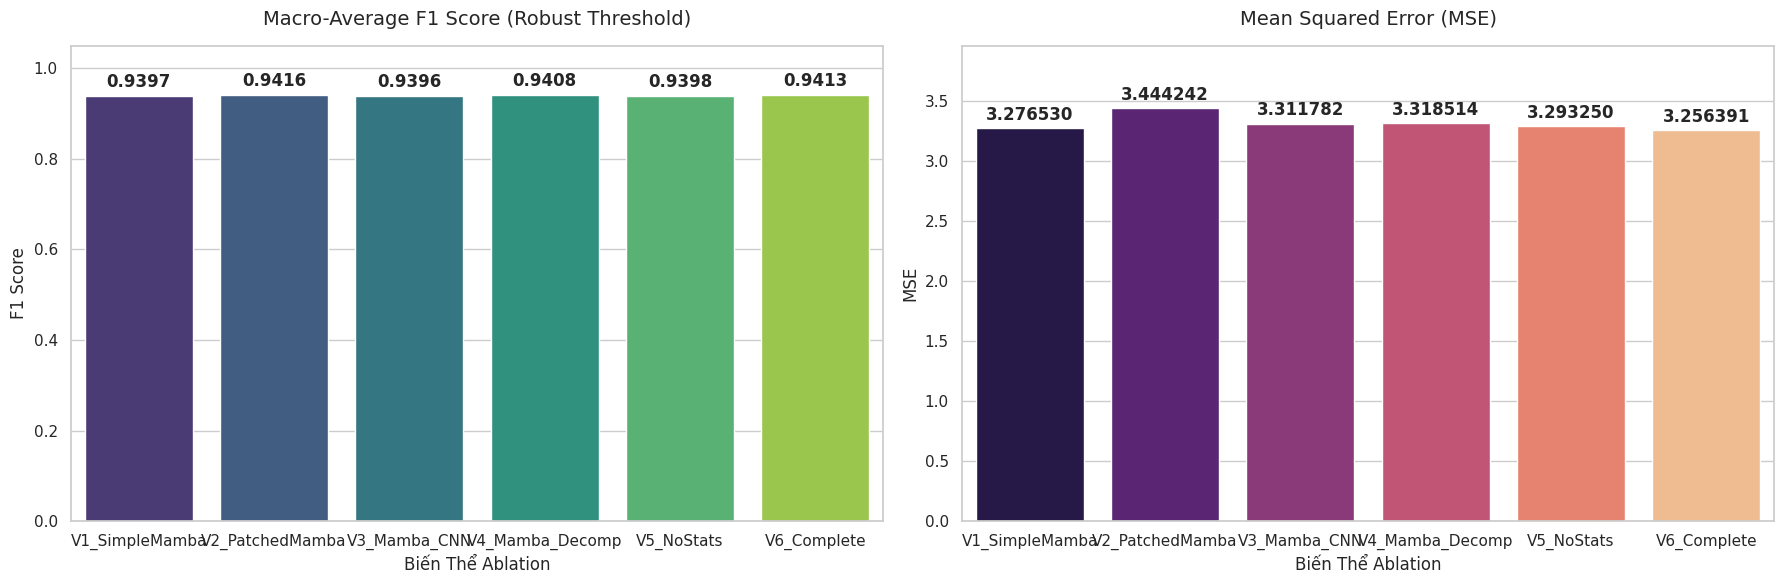

In [11]:
if eval_results:
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    variants = list(eval_results.keys())
    # Rút gọn tên hiển thị
    display_names = [v.replace("Variant_", "V") for v in variants]
    
    f1_robust = [eval_results[v]["F1 (Robust)"] for v in variants]
    mse_vals = [eval_results[v]["MSE"] for v in variants]
    
    # 1. Biểu đồ cột cho F1 Score
    sns.barplot(x=display_names, y=f1_robust, ax=axes[0], palette="viridis")
    axes[0].set_title("Macro-Average F1 Score (Robust Threshold)", fontsize=14, pad=15)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("F1 Score", fontsize=12)
    axes[0].set_xlabel("Biến Thể Ablation", fontsize=12)
    for i, v in enumerate(f1_robust):
        axes[0].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
        
    # 2. Biểu đồ cột cho MSE
    sns.barplot(x=display_names, y=mse_vals, ax=axes[1], palette="magma")
    axes[1].set_title("Mean Squared Error (MSE)", fontsize=14, pad=15)
    axes[1].set_ylabel("MSE", fontsize=12)
    axes[1].set_xlabel("Biến Thể Ablation", fontsize=12)
    max_mse = max(mse_vals) if len(mse_vals) > 0 else 1.0
    axes[1].set_ylim(0, max_mse * 1.15)
    for i, v in enumerate(mse_vals):
        axes[1].text(i, v + (max_mse * 0.02), f"{v:.6f}", ha='center', fontweight='bold')
        
    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu để vẽ biểu đồ.")

## 5. Trực Quan Hóa So Sánh Trên Từng Vòng Bi (Dual Y-Axis Plots)
Dưới đây là phần vẽ biểu đồ so sánh chi tiết ở mức sample (window-level) điểm dị thường (Anomaly Score MSE - log scale) cùng với các chỉ số vật lý RMS & Kurtosis thực tế trên từng vòng bi để phân tích chi tiết quá trình suy thoái của các biến thể.

Tìm thấy các vòng bi để trực quan hóa: ['B01', 'B03']
Đã lưu biểu đồ: /mnt/f/APPS_PJ/mamba-forecast-ad/results/plots/ablation_proof_B01_fa_md.png


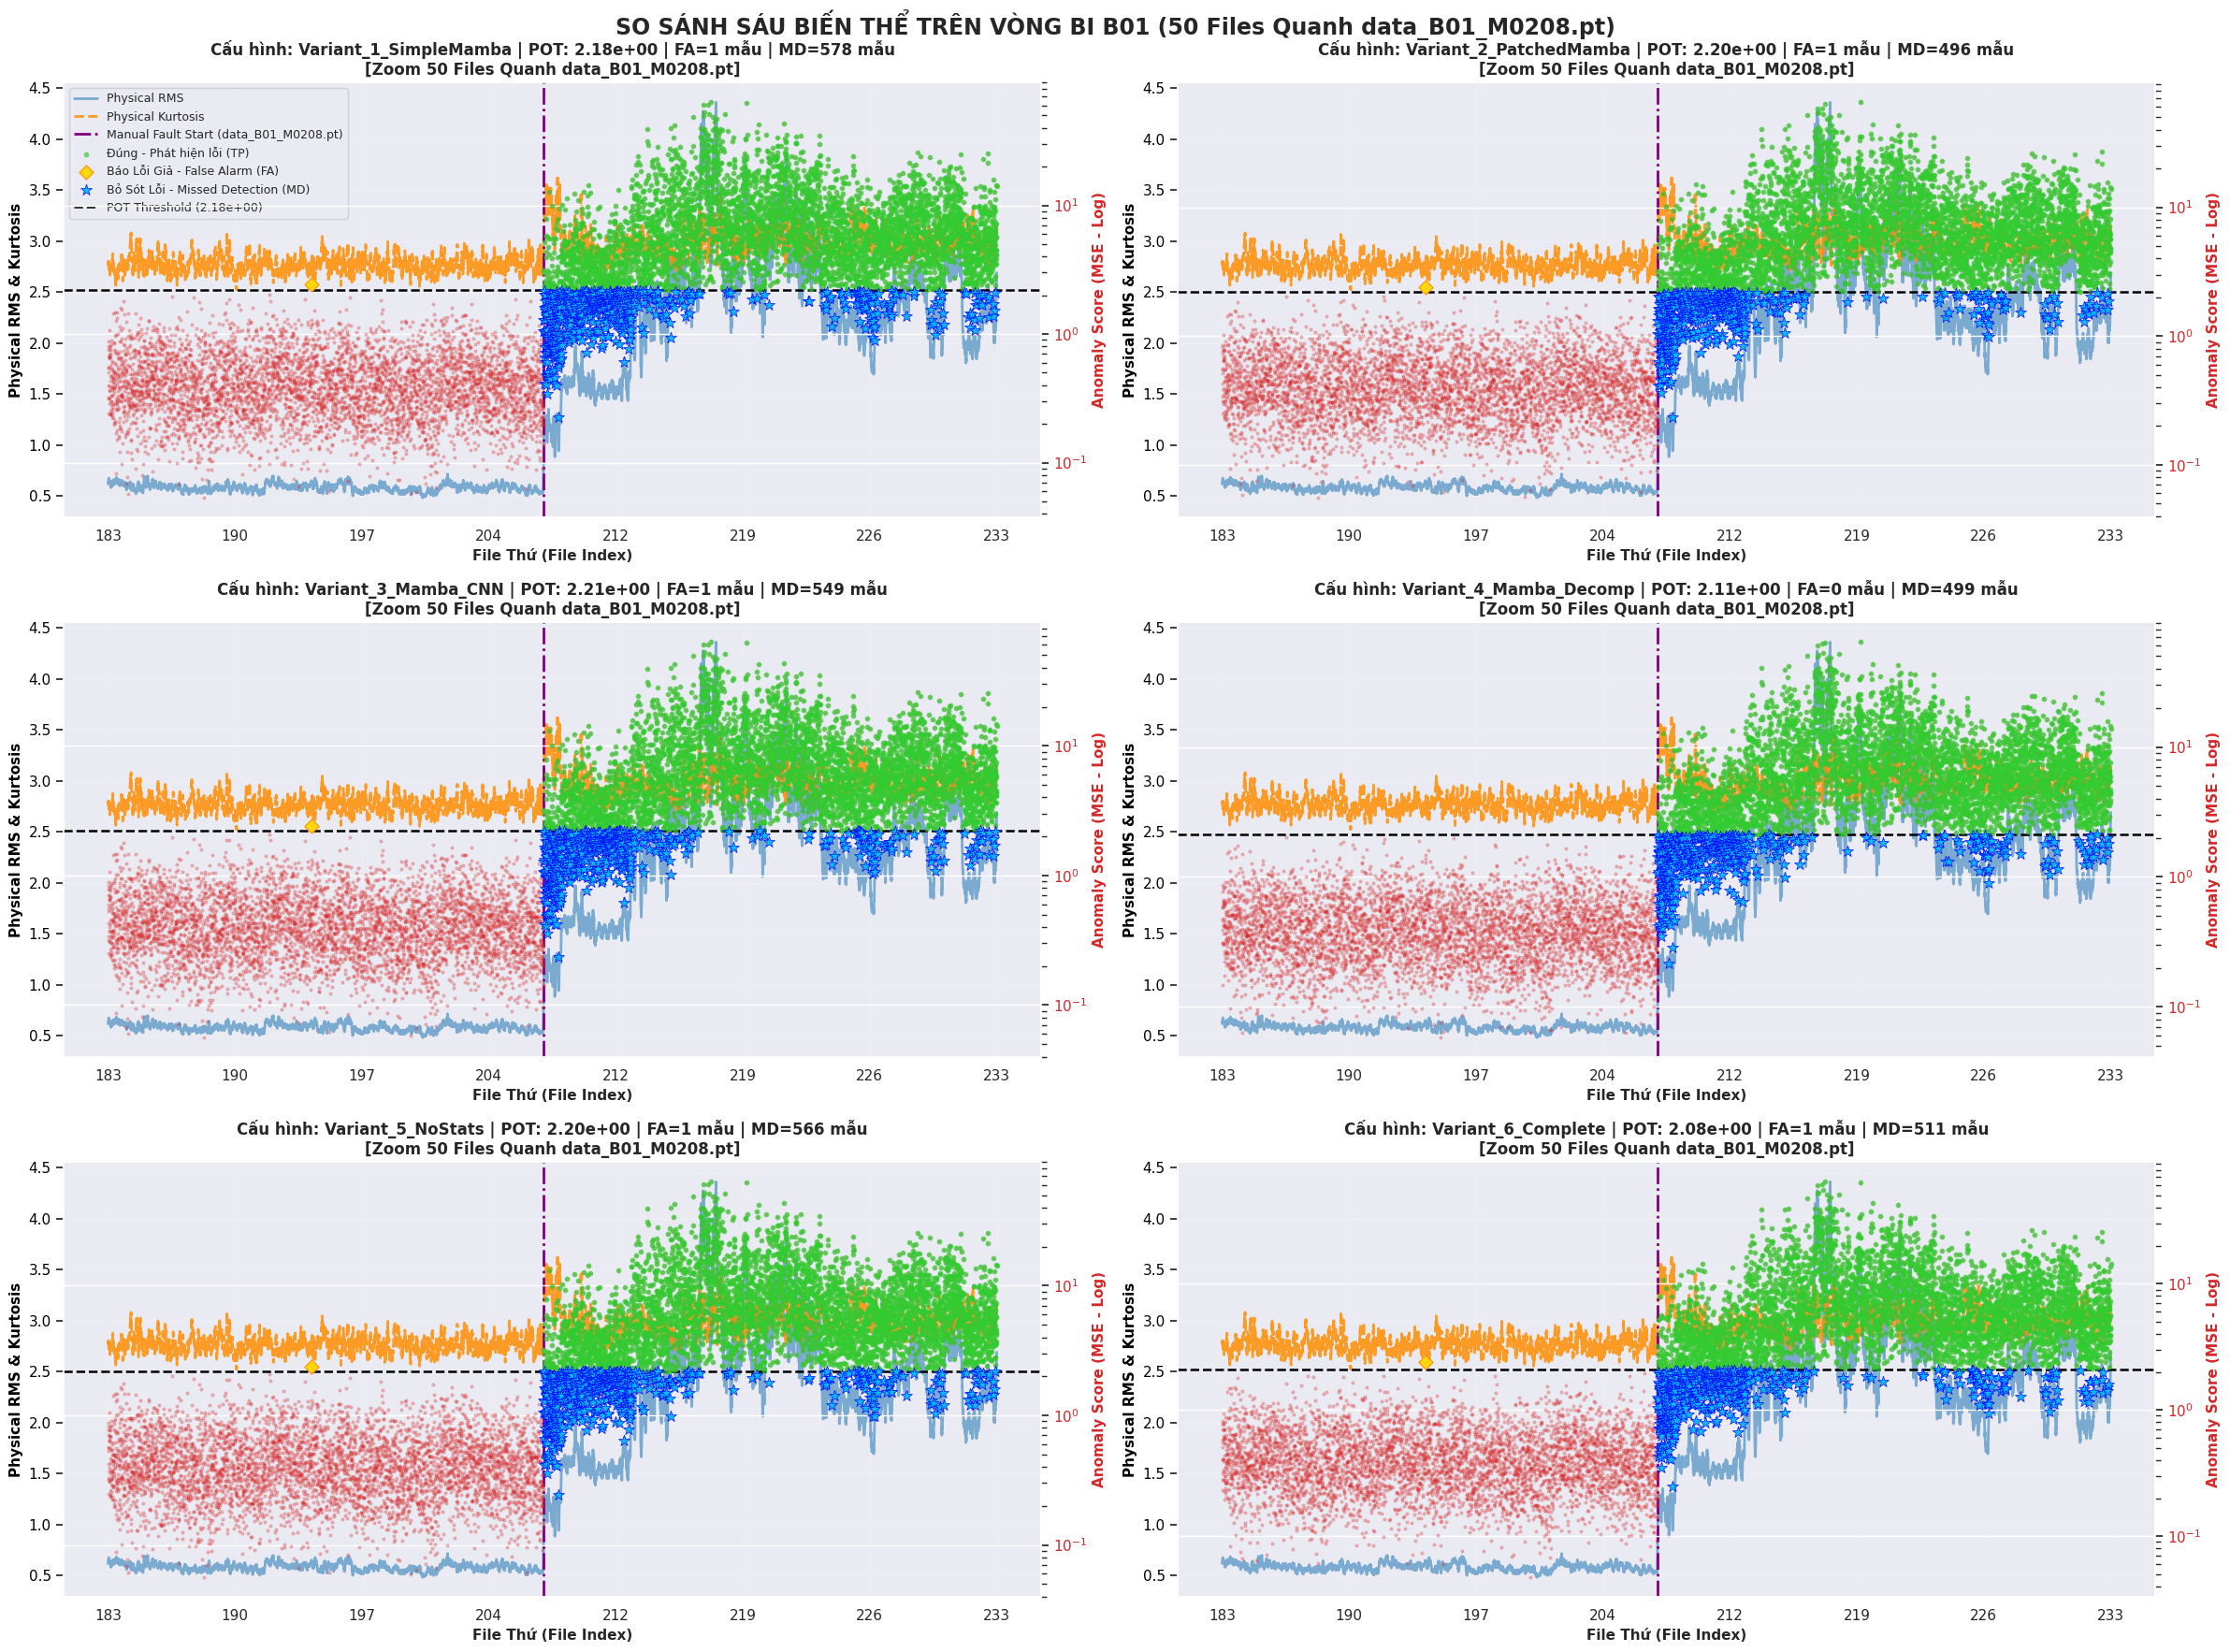

Đã lưu biểu đồ: /mnt/f/APPS_PJ/mamba-forecast-ad/results/plots/ablation_proof_B03_fa_md.png


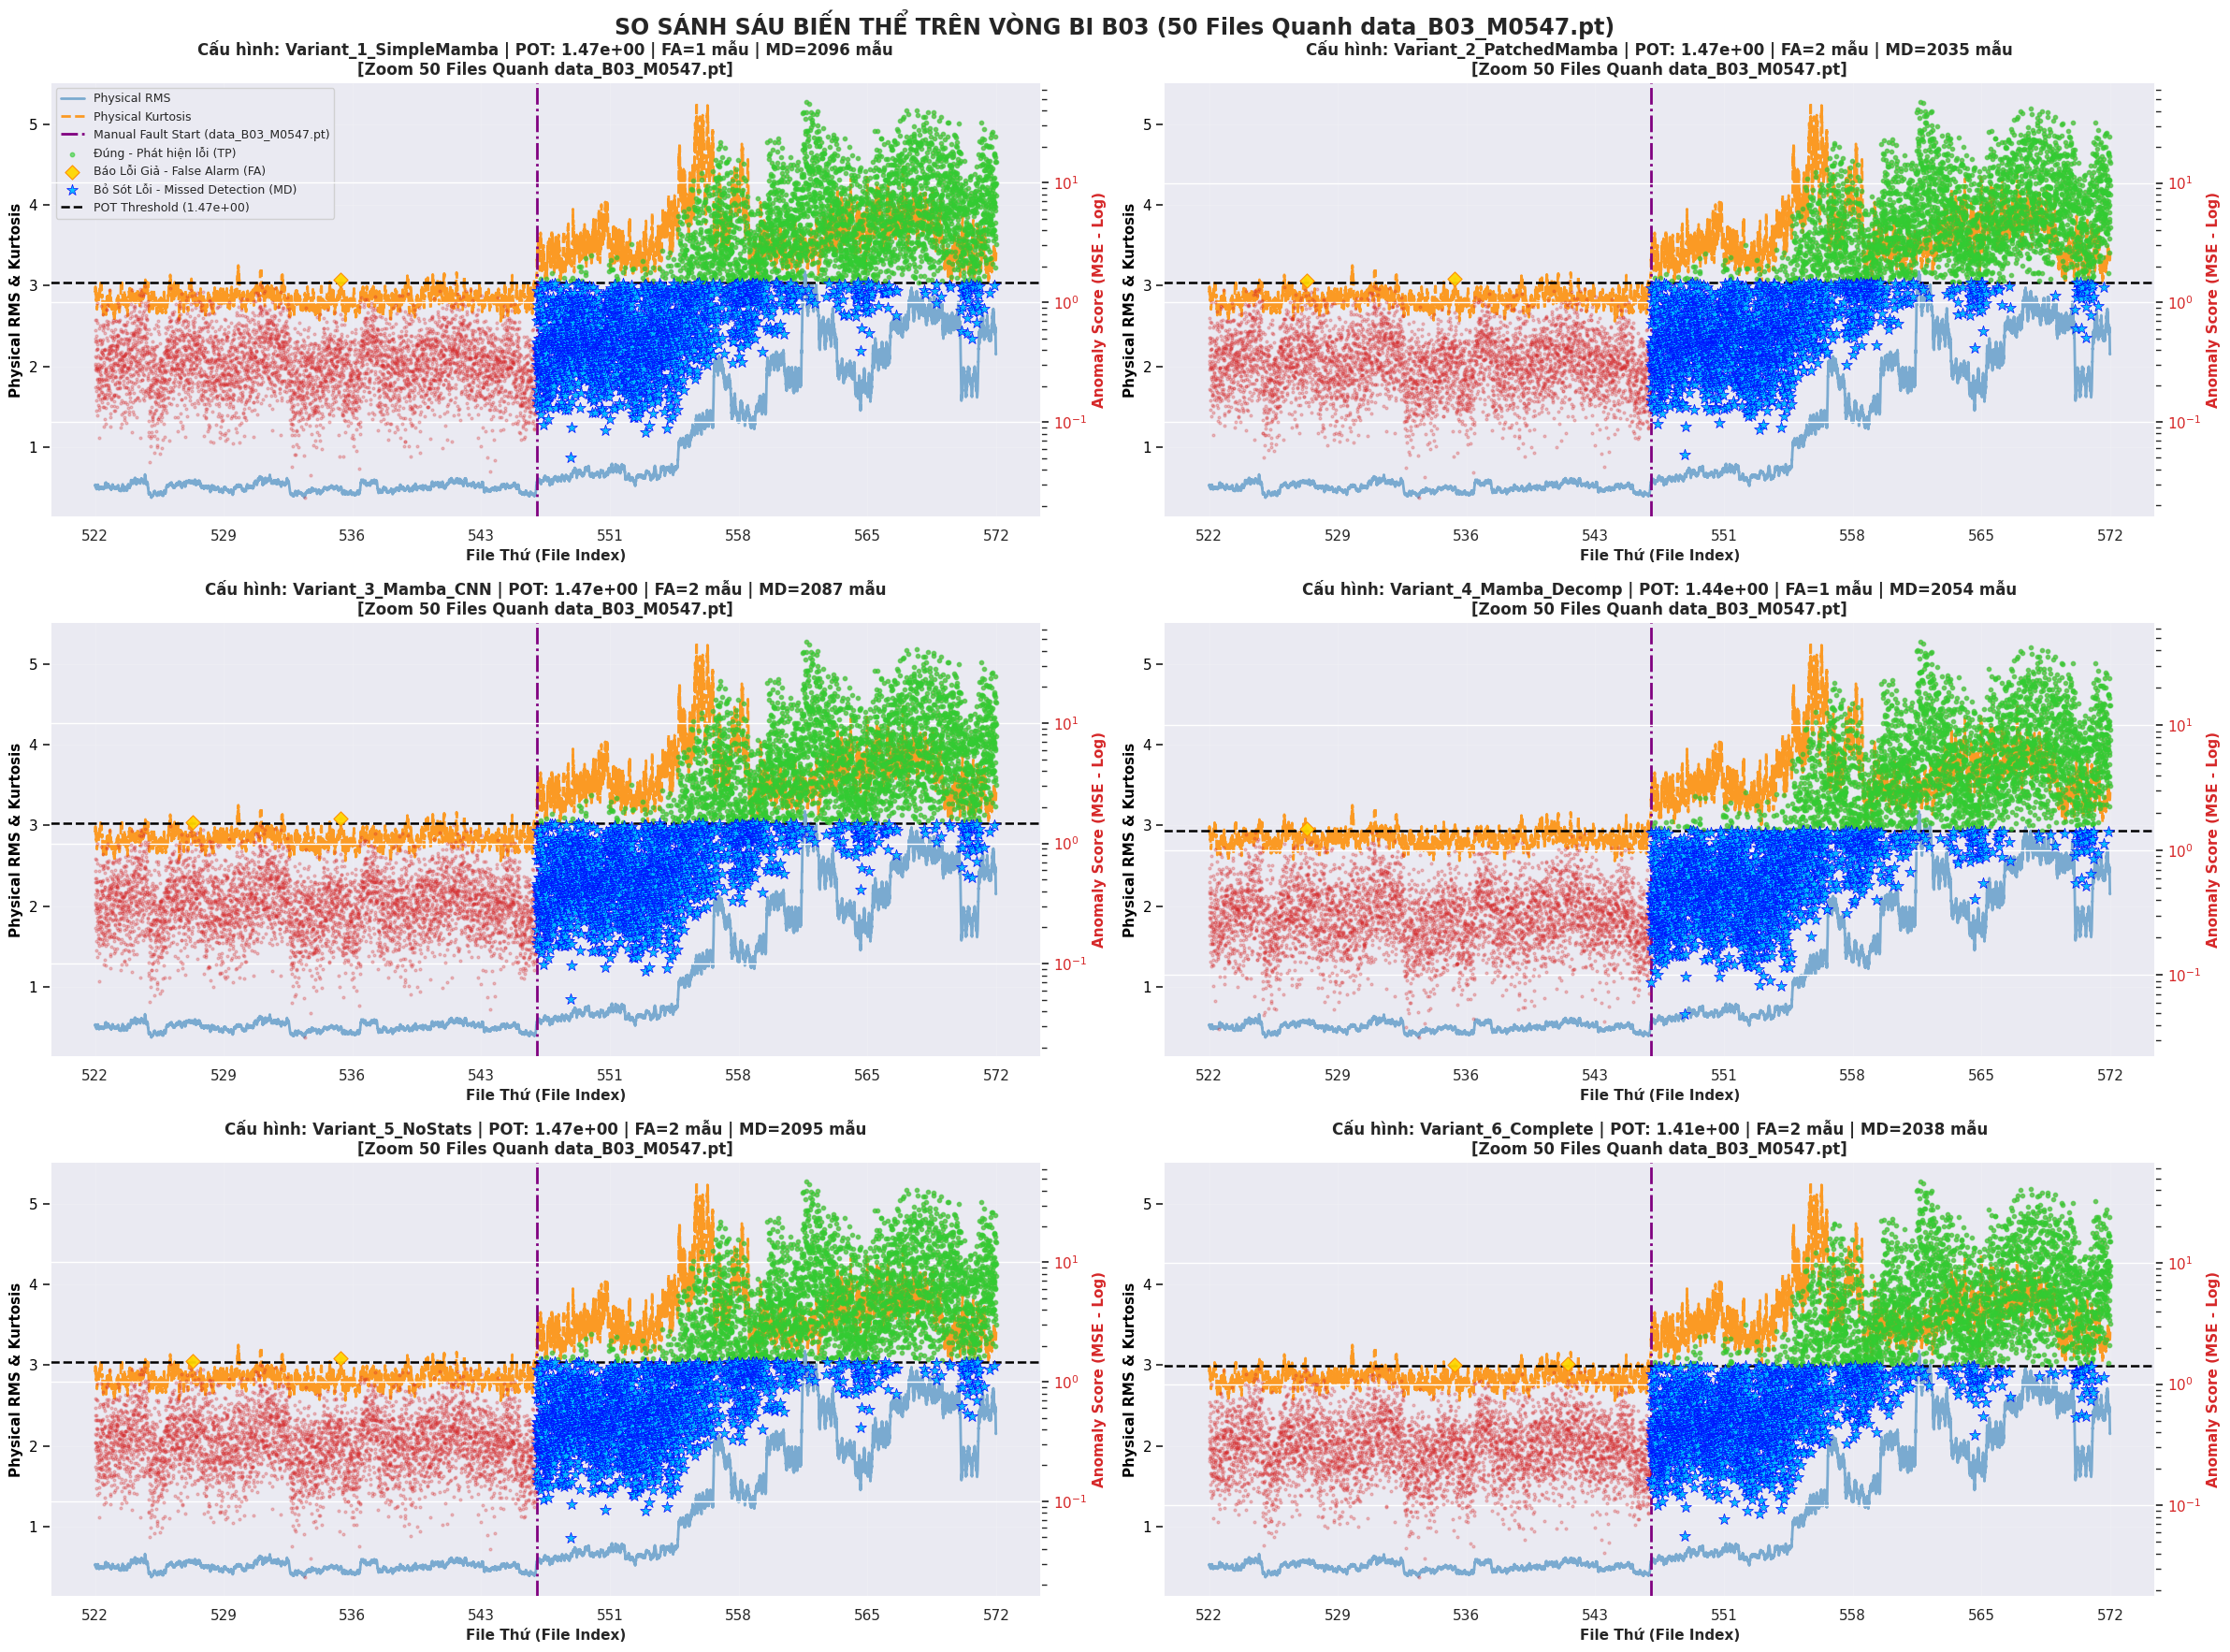

In [13]:
# --- TRỰC QUAN HÓA SO SÁNH TRÊN TỪNG VÒNG BI (Vẽ Dual Y-Axis + Highlight FA/MD) ---
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

if 'is_kaggle' in globals() and is_kaggle:
    plot_save_dir = "/kaggle/working/results/plots"
else:
    plot_save_dir = os.path.join(project_root, "results/plots")

os.makedirs(plot_save_dir, exist_ok=True)

POT_Q = 1e-3

# fault_start_files = {
#     "B01": "data_B01_M0208.pt",
#     "B03": "data_B03_M0555.pt"
# }

if 'comparison_results' in globals() and len(comparison_results) > 0:
    bearing_ids = sorted(list(comparison_results.keys()))
    print(f"Tìm thấy các vòng bi để trực quan hóa: {bearing_ids}")

    for b_id in bearing_ids:
        if len(comparison_results[b_id]) == 0:
            continue

        sorted_models = sorted(list(comparison_results[b_id].keys()))
        n_models = len(sorted_models)
        n_cols = 2
        n_rows = (n_models + 1) // 2

        sns.set_theme(style="darkgrid")
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6 * n_rows), sharex=False)

        if n_models == 1:
            axes = np.array([axes])
        else:
            axes = axes.flatten()

        for idx, cfg_name in enumerate(sorted_models):
            ax = axes[idx]
            res = comparison_results[b_id][cfg_name]

            scores      = np.array(res['mse'])
            file_indices = np.array(res['file_indices'])
            rms_vals    = np.array(res['rms'])
            kurt_vals   = np.array(res['kurtosis'])

            # Smooth RMS & Kurtosis
            rms_vals  = pd.Series(rms_vals).rolling(window=15, min_periods=1, center=True).mean().values
            kurt_vals = pd.Series(kurt_vals).rolling(window=15, min_periods=1, center=True).mean().values

            # POT threshold on first 20% healthy
            n_init = max(3, int(len(scores) * 0.2))
            threshold = calculate_threshold_pot(scores[:n_init], q=POT_Q) if len(scores) >= n_init else 1.0

            # Identify manual fault point
            target_file    = manual_fault_start.get(b_id)
            has_manual_fault = (target_file is not None
                                and 'files' in res
                                and target_file in res['files'])

            if has_manual_fault:
                start_idx  = res['files'].index(target_file)
                min_f_idx  = max(0, start_idx - 25)
                max_f_idx  = min(len(res['files']) - 1, start_idx + 25)
                mask       = (file_indices >= min_f_idx) & (file_indices <= max_f_idx)

                scores_sliced     = scores[mask]
                rms_sliced        = rms_vals[mask]
                kurt_sliced       = kurt_vals[mask]
                file_idx_sliced   = file_indices[mask]

                x_vals = np.arange(len(scores_sliced))
                highlight_idx = np.where(file_idx_sliced == start_idx)[0]
                highlight_x   = highlight_idx[0] if len(highlight_idx) > 0 else None

                x_label      = 'File Thứ (File Index)'
                title_suffix = f"\n[Zoom 50 Files Quanh {target_file}]"

                # Build local boolean: before / after fault boundary
                if highlight_x is not None:
                    before_fault = x_vals < highlight_x   # True = trước thời điểm lỗi
                    after_fault  = x_vals >= highlight_x  # True = sau thời điểm lỗi
                else:
                    before_fault = np.ones(len(x_vals), dtype=bool)
                    after_fault  = np.zeros(len(x_vals), dtype=bool)
            else:
                start_slice = int(len(scores) * 0.3)
                scores_sliced   = scores[start_slice:]
                rms_sliced      = rms_vals[start_slice:]
                kurt_sliced     = kurt_vals[start_slice:]
                file_idx_sliced = file_indices[start_slice:]
                x_vals          = np.arange(len(scores_sliced))
                highlight_x     = None
                x_label         = 'Mẫu (Sample)'
                title_suffix    = "\n[Vòng đời 30% - 100%]"
                before_fault    = np.ones(len(x_vals), dtype=bool)
                after_fault     = np.zeros(len(x_vals), dtype=bool)

            # ── LEFT AXIS: RMS & Kurtosis ────────────────────────────────────
            ax.plot(x_vals, rms_sliced,  color='tab:blue',   label='Physical RMS',      linewidth=2.0, alpha=0.55)
            ax.plot(x_vals, kurt_sliced, color='darkorange',  label='Physical Kurtosis', linewidth=2.0, alpha=0.85, linestyle='--')
            ax.set_ylabel('Physical RMS & Kurtosis', color='black', fontsize=11, fontweight='bold')
            ax.tick_params(axis='y', labelcolor='black')

            # ── RIGHT AXIS: Anomaly Score ────────────────────────────────────
            ax_twin = ax.twinx()

            # Classify samples into 4 categories
            above_thresh = scores_sliced > threshold
            below_thresh = ~above_thresh

            # 1. TRUE POSITIVE  — after fault  & above thresh  → correct alarm (green scatter on top)
            tp_mask = after_fault  & above_thresh
            # 2. TRUE NEGATIVE  — before fault & below thresh  → correct healthy (light red, small)
            tn_mask = before_fault & below_thresh
            # 3. FALSE ALARM    — before fault & above thresh  → báo lỗi giả (bright orange/yellow, big)
            fa_mask = before_fault & above_thresh
            # 4. MISSED DETECT  — after fault  & below thresh  → báo ổn định giả (bright blue, big)
            md_mask = after_fault  & below_thresh

            # Base line: all points faint red
            ax_twin.scatter(x_vals, scores_sliced, color='tab:red', s=4, alpha=0.25, zorder=2)

            # TP: correct alarms — lime green dots
            if tp_mask.any():
                ax_twin.scatter(x_vals[tp_mask], scores_sliced[tp_mask],
                                color='limegreen', s=10, alpha=0.6, zorder=3,
                                label='Đúng - Phát hiện lỗi (TP)')

            # TN: correct healthy — light blue-grey (already covered by base, no extra scatter needed)

            # FA: False Alarm — vivid orange diamond, large
            if fa_mask.any():
                ax_twin.scatter(x_vals[fa_mask], scores_sliced[fa_mask],
                                color='gold', marker='D', s=60, alpha=0.95,
                                edgecolors='darkorange', linewidths=0.8, zorder=5,
                                label='Báo Lỗi Giả - False Alarm (FA)')

            # MD: Missed Detection — vivid cyan star, large
            if md_mask.any():
                ax_twin.scatter(x_vals[md_mask], scores_sliced[md_mask],
                                color='deepskyblue', marker='*', s=80, alpha=0.95,
                                edgecolors='blue', linewidths=0.5, zorder=5,
                                label='Bỏ Sót Lỗi - Missed Detection (MD)')

            # POT threshold line
            ax_twin.axhline(y=threshold, color='black', linestyle='--', linewidth=1.8,
                            label=f'POT Threshold ({threshold:.2e})')

            # Fault boundary line
            if highlight_x is not None:
                ax.axvline(x=highlight_x, color='purple', linestyle='-.', linewidth=2.0,
                           label=f'Manual Fault Start ({target_file})')

            ax_twin.set_ylabel('Anomaly Score (MSE - Log)', color='tab:red', fontsize=11, fontweight='bold')
            ax_twin.tick_params(axis='y', labelcolor='tab:red')
            ax_twin.set_yscale('log')

            ax.grid(True, which="both", ls="-", alpha=0.15)

            # X-tick labels → file numbers
            if len(x_vals) > 1:
                tick_indices = np.linspace(0, len(x_vals) - 1, num=8, dtype=int)
                if has_manual_fault:
                    tick_labels = [f"{int(file_idx_sliced[i] + 1)}" for i in tick_indices]
                else:
                    pct = (np.arange(len(scores))[start_slice:] / max(np.arange(len(scores)))) * 100
                    tick_labels = [f"{pct[i]:.1f}%" for i in tick_indices]
                    x_label = 'Vị trí Vòng đời (%) | Life-cycle (%)'
                ax.set_xticks(tick_indices)
                ax.set_xticklabels(tick_labels)

            ax.set_xlabel(x_label, fontsize=11, fontweight='bold')

            # Count FA/MD for title annotation
            n_fa = int(fa_mask.sum())
            n_md = int(md_mask.sum())
            ax.set_title(
                f"Cấu hình: {cfg_name} | POT: {threshold:.2e} | FA={n_fa} mẫu | MD={n_md} mẫu{title_suffix}",
                fontsize=12, fontweight='bold'
            )

            # Combined legend (only on first subplot to save space)
            if idx == 0:
                lines1, labels1 = ax.get_legend_handles_labels()
                lines2, labels2 = ax_twin.get_legend_handles_labels()
                ax.legend(lines1 + lines2, labels1 + labels2,
                          loc='upper left', fontsize=9, framealpha=0.85)

        # Hide unused axes
        for unused_idx in range(n_models, len(axes)):
            fig.delaxes(axes[unused_idx])

        num_vi = {1:'MỘT', 2:'HAI', 3:'BA', 4:'BỐN', 5:'NĂM', 6:'SÁU'}
        num_word = num_vi.get(n_models, 'CÁC')

        main_title = f"SO SÁNH {num_word} BIẾN THỂ TRÊN VÒNG BI {b_id}"
        main_title += f" (50 Files Quanh {target_file})" if has_manual_fault else " (Full Life-cycle)"
        fig.suptitle(main_title, fontsize=17, fontweight='bold', y=0.98)
        plt.tight_layout()

        save_path = os.path.join(plot_save_dir, f"ablation_proof_{b_id}_fa_md.png")
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Đã lưu biểu đồ: {save_path}")
        plt.show()
else:
    print("Không tìm thấy comparison_results. Hãy chạy lại phần đánh giá mô hình.")
